## K-MEANS Clustering

In [49]:
from sentence_transformers import SentenceTransformer
import hdbscan
import json
import numpy as np

model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [50]:
# grab the OG dataset
with open("../finetuning-notebooks/formatted_polls.json", 'r') as jf:
    jdat = json.load(jf)

print(jdat[0])

pairings = []
for d in jdat:
    pairings.append({'a':d['optionA'], 'b':d['optionB'], 'context':d['title']})

print(f"# of Pairings: {len(pairings)}")

{'title': 'Would you rather always have your room be the perfect temperature when going to sleep or be able to immediately find the perfect sleeping position', 'optionA': 'always have your room be the perfect temperature when going to sleep', 'optionB': 'be able to immediately find the perfect sleeping position'}
# of Pairings: 313


In [ ]:
CATEGORIES = {
    "animals":                       ["animals", "pets", "creatures", "wildlife"],
    "body parts":                    ["body parts", "limbs", "organs", "physical features", "arms", "legs"],
    "money":                         ["money", "wealth", "finances", "$", "rich", "dollars", "currency"],
    "food / drink":                  ["food", "drink", "eating", "meals", "cooking", "drinking"],
    "life":                          ["life", "survival", "status", "well-being", "death", "dying", "mortality", "afterlife", "living forever"],
    "ability":                       ["superpower", "ability", "special ability", "magic power", "power", "skill", "be able to"],
    "curse":                         ["curse", "situation", "stuck", "trapped", "bewitched", "inhibited", "rules", "forced"],
    "age / time":                    ["age", "time", "youth", "old age", "going back in time"],
    "people":                        ["people", 'population', 'persons', 'everybody', 'strangers', 'neighbors', 'friends', "occupation", "job", "career"],
    "locations":                     ["location", "countries", "cities", "towns", "world", "space"],
    "sentience":                     ["become", "becoming", "inanimate", "transform", "stuck", "mutation", "live as inanimate object", "be a", "be an"],
    "miscellaneous":                 ["miscellaneous", "other", "general", "random", "unrelated"],
}

MISC_THRESH = 0.50
 
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


 
closest_category = "n/a"
second_score = 0
def categorize_pairing(model, pairing, category_embeddings):
    # Combine both options into one text for embedding
    combined = f"{pairing['a']} or {pairing['b']}"
    query_embedding = model.encode(combined)
 
    best_category = None
    best_score = -1
 
    for category, phrase_embeddings in category_embeddings.items():
        # Score = max similarity across all representative phrases for this category
        scores = [cosine_similarity(query_embedding, pe) for pe in phrase_embeddings]
        score = max(scores)
        if score > best_score:
            closest_category = best_category
            second_score = best_score
            best_score = score
            best_category = category

        elif second_score < score:
            closest_category = category
            second_score = score

    if best_score < MISC_THRESH:
        closest_category = best_category
        best_category = "miscellaneous"
        
 
    return {**pairing, "main_category": best_category, "secondary_category":closest_category, "score": round(float(best_score), 4)}
 

 


In [ ]:
def main():
 
    print("Pre-computing category embeddings...")
    category_embeddings = {
        cat: model.encode(phrases)
        for cat, phrases in CATEGORIES.items()
    }
 
    print(f"\nCategorizing {len(pairings)} pairings...\n")
    results = []
 
    for i, pairing in enumerate(pairings, 1):
        result = categorize_pairing(model, pairing, category_embeddings)
        results.append(result)
        print(f"[{i}] A: {result['a']!r}  |  B: {result['b']!r}")
        print(f"     Category : {result['main_category']}  (score: {result['score']})\n")
 
    # Optional: save to JSON
    import json
    with open("categorized_pairings.json", "w") as f:
        json.dump(results, f, indent=2)
    print("Results saved to categorized_pairings.json")

In [54]:
main()

Loading model...
Pre-computing category embeddings...

Categorizing 313 pairings...

[1] A: 'always have your room be the perfect temperature when going to sleep'  |  B: 'be able to immediately find the perfect sleeping position'
     Category : ability  (score: 0.6207)

[2] A: 'be bound to the same spot everyday for 5 hours at a time (body not and you are standing upward NOT comfortable) but for every word you speak during that time you get a dollar'  |  B: 'be a sentient weasel being exploited by a circus as a freak animal who can understand english'
     Category : curse  (score: 0.5664)

[3] A: "everytime somebody around you said the magic word (but the radius of 'around' is like 100 km) you get given 12 donuts"  |  B: 'just have a permanent casual job as a grave representer so you vouch for dead people whenever you want to get prettier graves'
     Category : life  (score: 0.5208)

[4] A: "feel like you're being slightly tickled by a feather on your feet all the time (and never ge

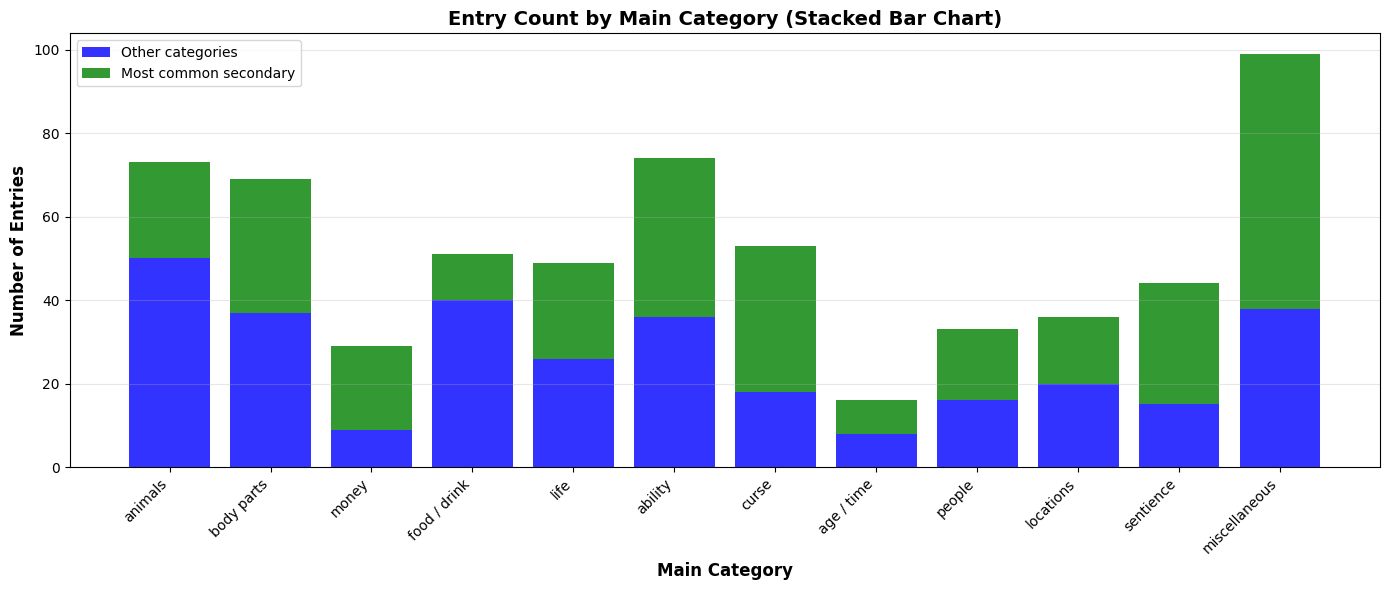

In [61]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict


def vis_data_cat(filename):
    # Load the categorized pairings data
    with open(filename, 'r') as f:
        data = json.load(f)

    # Count entries by main and secondary category
    category_counts = defaultdict(lambda: defaultdict(int))

    main_cts = {}
    second_cts = {}
    for entry in data:
        main = entry['main_category']
        secondary = entry['secondary_category']
        if main not in main_cts:
            main_cts[main] = 0
        main_cts[main] += 1
        if secondary not in second_cts:
            second_cts[secondary] = 0
        second_cts[secondary] += 1

    # For each main category, identify the most common secondary category
    all_categories = sorted(category_counts.keys())
    most_common_secondary = {}
    other_counts = {}

    # print(main_cts)
    # print(second_cts)

    # Prepare data for stacked bar chart
    blue_values = [main_cts[m] for m in CATEGORIES]
    green_values = [second_cts[m] for m in CATEGORIES]

    # print(blue_values)

    # Create the stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 6))

    x_pos = range(len(CATEGORIES))
    ax.bar(x_pos, blue_values, label='Other categories', color='blue', alpha=0.8)
    ax.bar(x_pos, green_values, bottom=blue_values, label='Most common secondary', color='green', alpha=0.8)

    ax.set_xlabel('Main Category', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Entries', fontsize=12, fontweight='bold')
    ax.set_title('Entry Count by Main Category (Stacked Bar Chart)', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(CATEGORIES, rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../category_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()


vis_data_cat("categorized_pairings.json")

# Print summary
# print("\nEntry Counts by Main Category:")
# print("-" * 60)
# for main in CATEGORIES:
#     total = blue_values[CATEGORIES.index(main)] + green_values[main_categories.index(main)]
#     print(f"{main:20} - Other: {blue_values[CATEGORIES.index(main)]:3}, Most Common: {green_values[main_categories.index(main)]:3}, Total: {total}")
# print("-" * 60)
# print(f"Total entries: {len(data)}")

## Categorize Generated Questions

Loaded 1566 entries from wyr_votes.db

Unique models: ['deepseek', 'gemma', 'llama', 'meta-llama', 'qwen', 'smol', 'tencent', 'tinyllama']

Data sample:
  model_name  option_a  option_b
0      llama  option A  option B
1       smol  option A  option B
2       qwen  option A  option B
3      gemma  option A  option B
4      llama  option A  option B

Entry counts per model:
model_name
deepseek        1
gemma         330
llama         209
meta-llama    122
qwen          331
smol          331
tencent       120
tinyllama     122
Name: count, dtype: int64


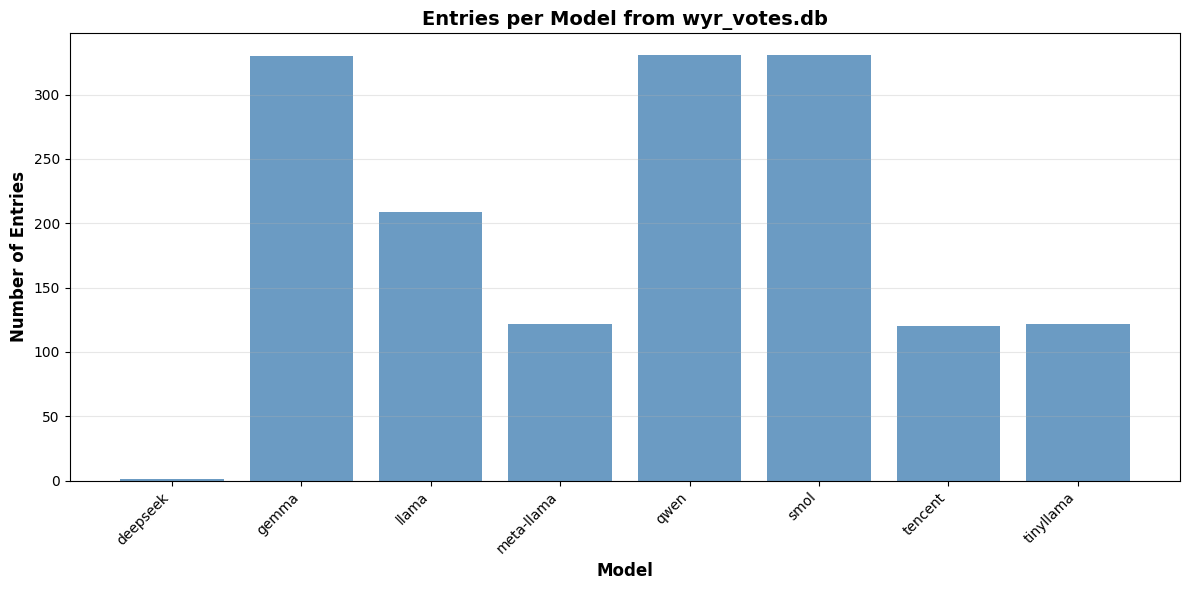


Chart saved as 'model_entries_visualization.png'


In [2]:
# import the generated questions 
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Connect to SQLite database
conn = sqlite3.connect('../wyr_votes.db')
cursor = conn.cursor()

# Load data from database
query = "SELECT model_name, option_a, option_b FROM model_outputs"
df = pd.read_sql_query(query, conn)
conn.close()

print(f"Loaded {len(df)} entries from wyr_votes.db")
print(f"\nUnique models: {sorted(df['model_name'].unique())}")
print(f"\nData sample:")
print(df.head())

# Count entries per model
model_counts = df['model_name'].value_counts().sort_index()
print(f"\nEntry counts per model:")
print(model_counts)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))
models = model_counts.index
counts = model_counts.values

ax.bar(models, counts, color='steelblue', alpha=0.8)
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Entries', fontsize=12, fontweight='bold')
ax.set_title('Entries per Model from wyr_votes.db', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../model_entries_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nChart saved as 'model_entries_visualization.png'")

In [3]:
category_embeddings = {
    cat: model.encode(phrases)
    for cat, phrases in CATEGORIES.items()
}

print(f"\nCategorizing {len(df)} pairings...\n")
results = []

for i, pairing in enumerate(df, 1):
    result = categorize_pairing(model, df, category_embeddings)
    results.append(result)
    print(f"[{i}] A: {result['a']!r}  |  B: {result['b']!r}")
    print(f"     Category : {result['main_category']}  (score: {result['score']})\n")

# Optional: save to JSON
import json
with open("categorized_pairings.json", "w") as f:
    json.dump(results, f, indent=2)
print("Results saved to categorized_pairings.json")

NameError: name 'CATEGORIES' is not defined